In [2]:
# monter drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset chargé : 5152 articles
Distribution   : {1: 2576, 0: 2576}

Train : 4121 | Test : 1031

VERSION : TF-IDF + SVM — V1 (Titre seul)
Entraînement en cours...
✅ Entraînement terminé

Résultats :
              precision    recall  f1-score   support

        Réel       0.80      0.77      0.78       516
        Fake       0.78      0.80      0.79       515

    accuracy                           0.79      1031
   macro avg       0.79      0.79      0.79      1031
weighted avg       0.79      0.79      0.79      1031

Accuracy : 0.7876 | F1 : 0.7875 | AUC : 0.8599

VERSION : TF-IDF + SVM — V2 (Titre + Texte)
Entraînement en cours...
✅ Entraînement terminé

Résultats :
              precision    recall  f1-score   support

        Réel       0.82      0.84      0.83       516
        Fake       0.84      0.82      0.83       515

    accuracy                           0.83      1031
   macro avg       0.83      0.83      0.83      1031
weighted avg       0.83      0.83      0.83      1

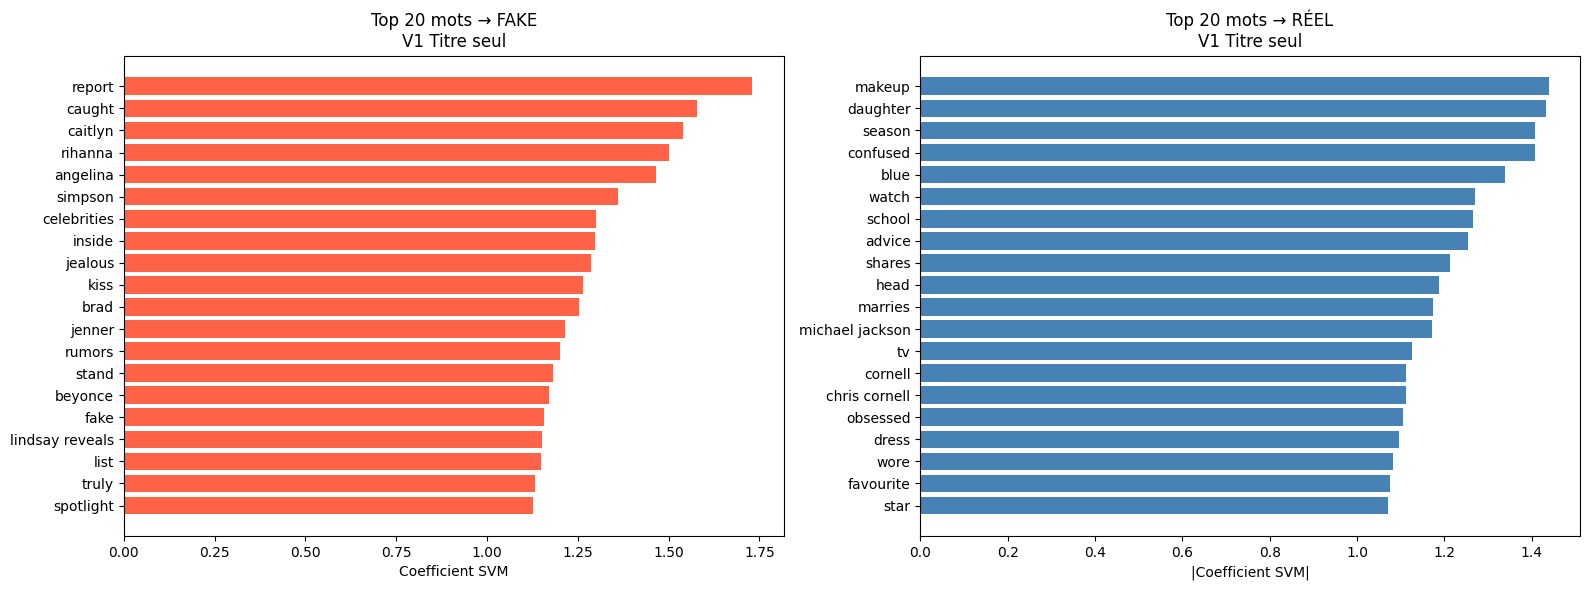

✅ Graphe sauvegardé : tfidf_features_V1_Titre_seul.png


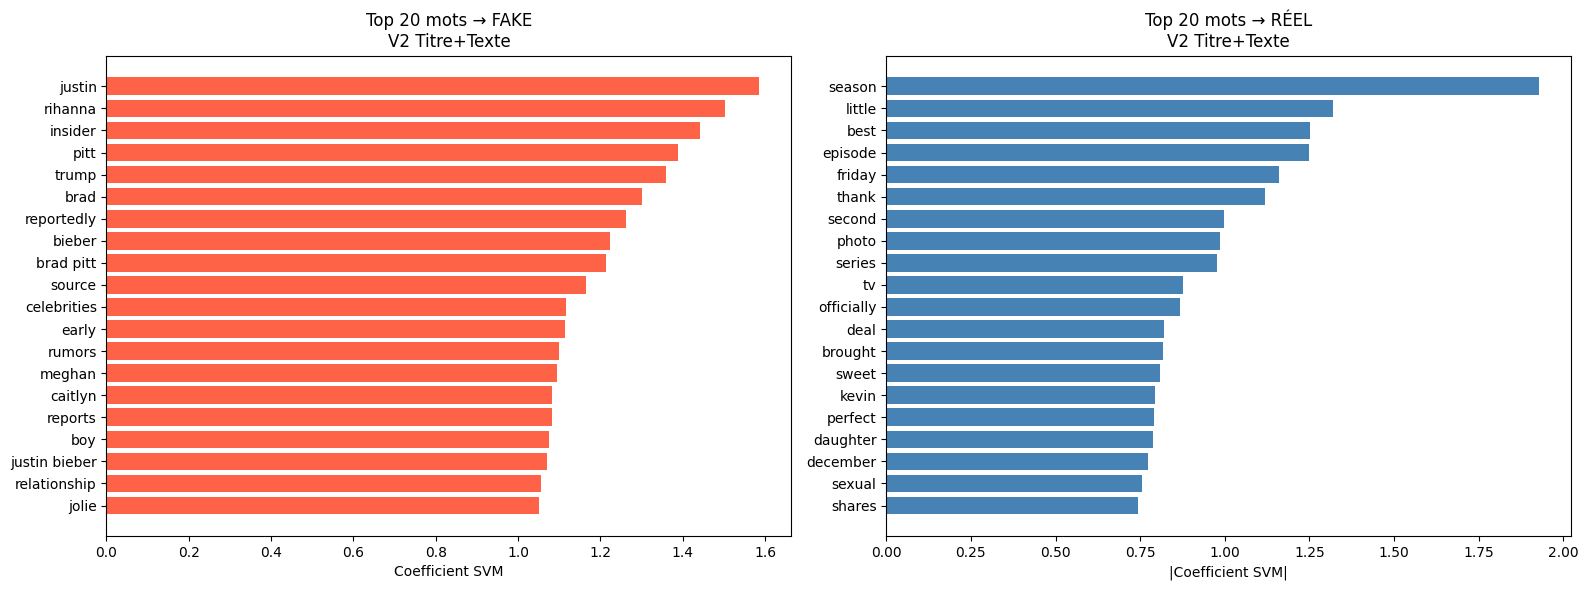

✅ Graphe sauvegardé : tfidf_features_V2_Titre+Texte.png


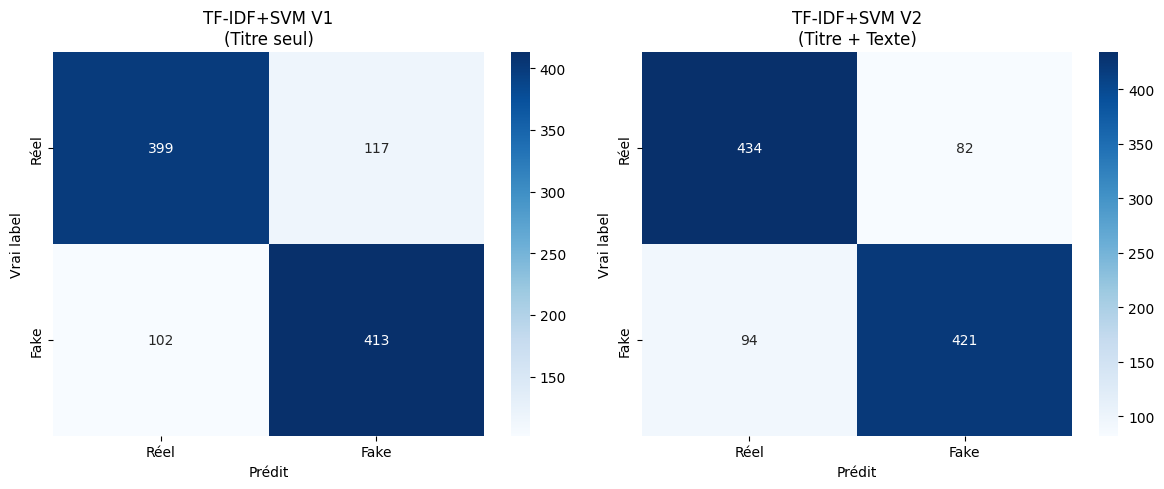

✅ Matrices de confusion sauvegardées

TABLEAU COMPARATIF COMPLET — GossipCop équilibré
Modèle                                Accuracy       F1      AUC
-----------------------------------------------------------------
TF-IDF+SVM V1 (titre seul)              0.7876   0.7875   0.8599
TF-IDF+SVM V2 (titre+texte)             0.8293   0.8293   0.9066
BERT + Source + KG (M1+M2+M3)                ⏳        ⏳        ⏳

💡 Interprétation attendue :
   TF-IDF+SVM V1 < TF-IDF+SVM V2 < BERT+Source
   → Chaque étape apporte une amélioration mesurable


In [3]:
# ============================================================
# BASELINE — TF-IDF + SVM
# V1 : Titre seul
# V2 : Titre + Texte
# ============================================================

import pandas as pd
import numpy as np
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report,
                             confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# ÉTAPE 1 — CHARGEMENT DU DATASET
# ============================================================

def load_dataset(filepath):
    df = pd.read_csv(filepath)

    # Extraction domaine si absent
    if 'domain' not in df.columns:
        def extract_domain(url):
            try:
                url = str(url).strip()
                if not url.startswith('http'):
                    url = 'http://' + url
                return urlparse(url).netloc.replace('www.', '').strip()
            except:
                return 'unknown'
        df['domain'] = df['url'].apply(extract_domain)

    df['title']  = df['title'].fillna('')
    df['text']   = df['text'].fillna('')
    df['label']  = df['label'].astype(int)
    df = df.dropna(subset=['label']).reset_index(drop=True)

    # ✅ V1 : titre seul
    df['input_v1'] = df['title']

    # ✅ V2 : titre + 150 premiers mots du texte
    df['input_v2'] = (
        df['title'] + ' ' +
        df['text'].apply(lambda t: ' '.join(str(t).split()[:150]))
    ).str.strip()

    print(f"Dataset chargé : {len(df)} articles")
    print(f"Distribution   : {df['label'].value_counts().to_dict()}")
    return df

df = load_dataset('/content/drive/MyDrive/fakenewsnet_gossipcop_balanced.csv')

# ============================================================
# ÉTAPE 2 — SPLIT TRAIN/TEST
# (même split que BERT pour comparaison équitable)
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nTrain : {len(train_df)} | Test : {len(test_df)}")

# Inputs V1 et V2
X_train_v1 = train_df['input_v1'].tolist()
X_test_v1  = test_df['input_v1'].tolist()

X_train_v2 = train_df['input_v2'].tolist()
X_test_v2  = test_df['input_v2'].tolist()

y_train = train_df['label'].tolist()
y_test  = test_df['label'].tolist()


# ============================================================
# ÉTAPE 3 — CONSTRUCTION DES PIPELINES TF-IDF + SVM
# ============================================================

def build_pipeline():
    """
    Pipeline TF-IDF + SVM calibré.

    TF-IDF : transforme le texte en vecteur de features
             basées sur la fréquence des mots.

    LinearSVC : classifieur SVM linéaire, très efficace
                sur les données textuelles.

    CalibratedClassifierCV : encapsule le SVM pour produire
                             des probabilités (nécessaire pour AUC).
    """
    tfidf = TfidfVectorizer(
        max_features=50000,     # 50k mots maximum
        ngram_range=(1, 2),     # unigrammes ET bigrammes
        sublinear_tf=True,      # log(tf) au lieu de tf brut
        min_df=2,               # ignore les mots rares (< 2 occurrences)
        strip_accents='unicode',
        analyzer='word',
        stop_words='english'
    )

    svm = LinearSVC(
        C=1.0,                  # paramètre de régularisation
        max_iter=2000,
        random_state=42
    )

    # CalibratedClassifierCV donne accès aux probabilités
    calibrated_svm = CalibratedClassifierCV(svm, cv=3)

    pipeline = Pipeline([
        ('tfidf', tfidf),
        ('clf',   calibrated_svm)
    ])

    return pipeline


# ============================================================
# ÉTAPE 4 — ENTRAÎNEMENT ET ÉVALUATION
# ============================================================

def train_and_evaluate(pipeline, X_train, X_test, y_train, y_test, version_name):
    """
    Entraîne le pipeline et évalue les performances.
    Retourne un dict de métriques.
    """
    print(f"\n{'='*55}")
    print(f"VERSION : {version_name}")
    print(f"{'='*55}")

    # Entraînement
    print("Entraînement en cours...")
    pipeline.fit(X_train, y_train)
    print("✅ Entraînement terminé")

    # Prédictions
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  # proba classe fake

    # Métriques
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)

    print(f"\nRésultats :")
    print(classification_report(y_test, y_pred,
                                target_names=['Réel', 'Fake']))
    print(f"Accuracy : {acc:.4f} | F1 : {f1:.4f} | AUC : {auc:.4f}")

    return {
        'version':  version_name,
        'accuracy': acc,
        'f1':       f1,
        'auc':      auc,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'pipeline': pipeline
    }


# ============================================================
# ÉTAPE 5 — LANCEMENT DES DEUX VERSIONS
# ============================================================

# V1 — Titre seul
pipeline_v1 = build_pipeline()
results_v1  = train_and_evaluate(
    pipeline_v1,
    X_train_v1, X_test_v1,
    y_train, y_test,
    version_name="TF-IDF + SVM — V1 (Titre seul)"
)

# V2 — Titre + Texte
pipeline_v2 = build_pipeline()
results_v2  = train_and_evaluate(
    pipeline_v2,
    X_train_v2, X_test_v2,
    y_train, y_test,
    version_name="TF-IDF + SVM — V2 (Titre + Texte)"
)


# ============================================================
# ÉTAPE 6 — ANALYSE DES FEATURES IMPORTANTES
# ============================================================

def plot_top_features(pipeline, version_name, n=20):
    """
    Affiche les mots les plus discriminants pour chaque classe.
    C'est une analyse qualitative très utile pour le mémoire.
    """
    tfidf     = pipeline.named_steps['tfidf']
    clf       = pipeline.named_steps['clf']
    base_clf  = clf.calibrated_classifiers_[0].estimator

    feature_names = np.array(tfidf.get_feature_names_out())
    coefs         = base_clf.coef_[0]  # coefficients SVM

    # Top mots pour "Fake" (coefficients positifs)
    top_fake_idx  = np.argsort(coefs)[-n:][::-1]
    top_fake_words = feature_names[top_fake_idx]
    top_fake_coefs = coefs[top_fake_idx]

    # Top mots pour "Réel" (coefficients négatifs)
    top_real_idx  = np.argsort(coefs)[:n]
    top_real_words = feature_names[top_real_idx]
    top_real_coefs = coefs[top_real_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Mots fake
    colors_fake = ['tomato'] * n
    ax1.barh(range(n), top_fake_coefs[::-1], color=colors_fake)
    ax1.set_yticks(range(n))
    ax1.set_yticklabels(top_fake_words[::-1])
    ax1.set_title(f'Top {n} mots → FAKE\n{version_name}')
    ax1.set_xlabel('Coefficient SVM')

    # Mots réels
    colors_real = ['steelblue'] * n
    ax2.barh(range(n), np.abs(top_real_coefs[::-1]), color=colors_real)
    ax2.set_yticks(range(n))
    ax2.set_yticklabels(top_real_words[::-1])
    ax2.set_title(f'Top {n} mots → RÉEL\n{version_name}')
    ax2.set_xlabel('|Coefficient SVM|')

    plt.tight_layout()
    fname = f"tfidf_features_{version_name.replace(' ', '_')[:20]}.png"
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✅ Graphe sauvegardé : {fname}")

print("\n📊 Analyse des features importantes...")
plot_top_features(pipeline_v1, "V1 Titre seul")
plot_top_features(pipeline_v2, "V2 Titre+Texte")


# ============================================================
# ÉTAPE 7 — MATRICES DE CONFUSION
# ============================================================

def plot_confusion_matrix(results, ax, title):
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Réel', 'Fake'],
        yticklabels=['Réel', 'Fake'],
        ax=ax
    )
    ax.set_title(title)
    ax.set_ylabel('Vrai label')
    ax.set_xlabel('Prédit')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_matrix(results_v1, ax1, 'TF-IDF+SVM V1\n(Titre seul)')
plot_confusion_matrix(results_v2, ax2, 'TF-IDF+SVM V2\n(Titre + Texte)')
plt.tight_layout()
plt.savefig('tfidf_confusion_matrices.png', dpi=120)
plt.show()
print("✅ Matrices de confusion sauvegardées")


# ============================================================
# ÉTAPE 8 — TABLEAU COMPARATIF FINAL
# ============================================================

print("\n" + "="*65)
print("TABLEAU COMPARATIF COMPLET — GossipCop équilibré")
print("="*65)
print(f"{'Modèle':<35} {'Accuracy':>10} {'F1':>8} {'AUC':>8}")
print("-"*65)

# Baselines TF-IDF
print(f"{'TF-IDF+SVM V1 (titre seul)':<35} "
      f"{results_v1['accuracy']:>10.4f} "
      f"{results_v1['f1']:>8.4f} "
      f"{results_v1['auc']:>8.4f}")

print(f"{'TF-IDF+SVM V2 (titre+texte)':<35} "
      f"{results_v2['accuracy']:>10.4f} "
      f"{results_v2['f1']:>8.4f} "
      f"{results_v2['auc']:>8.4f}")



# À compléter
print(f"{'BERT + Source + KG (M1+M2+M3)':<35} "
      f"{'⏳':>10} {'⏳':>8} {'⏳':>8}")

print("="*65)
print("\n💡 Interprétation attendue :")
print("   TF-IDF+SVM V1 < TF-IDF+SVM V2 < BERT+Source")
print("   → Chaque étape apporte une amélioration mesurable")

In [3]:
# ============================================================
# SAUVEGARDE — TF-IDF + SVM
# ============================================================
import os
import pickle

# Crée le dossier models sur Drive
os.makedirs('/content/drive/MyDrive/models', exist_ok=True)

# Sauvegarde V1 (titre seul)
with open('/content/drive/MyDrive/models/tfidf_svm_v1_titre.pkl', 'wb') as f:
    pickle.dump(pipeline_v1, f)

# Sauvegarde V2 (titre + texte)
with open('/content/drive/MyDrive/models/tfidf_svm_v2_titre_texte.pkl', 'wb') as f:
    pickle.dump(pipeline_v2, f)

print("✅ Modèles TF-IDF+SVM sauvegardés dans /models/")

✅ Modèles TF-IDF+SVM sauvegardés dans /models/
